# Install/import libraries:


In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

# Functions:


## Other functions:


In [2]:
def k_loop_bin(nx, ny, nz, tke_spectrum, tkeh):
    """
    Compute and bin the turbulent kinetic energy (TKE) spectrum in spectral space.

    Parameters:
    -----------
    nx, ny, nz : int
        Number of grid points in the x, y, and z directions.
    tke_spectrum : np.ndarray
        1D array to accumulate the TKE values binned by wavenumbers.
    tkeh : np.ndarray
        3D array containing the spectral kinetic energy values.

    Returns:
    --------
    tke_spectrum : np.ndarray
        Updated TKE spectrum array binned by wavenumbers.
    """
    # Create a range of kx, ky, kz
    kx = np.arange(-nx // 2, nx // 2)
    ky = np.arange(-ny // 2, ny // 2)
    kz = np.arange(-nz // 2, nz // 2)

    # Create a meshgrid
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")

    # Compute rk in a vectorized manner
    rk = np.sqrt(KX**2 + KY**2 + KZ**2)

    # Round to the nearest integer to get k
    k = np.round(rk).astype(int)

    # Create a mask to avoid out-of-bounds indices
    mask = k < tke_spectrum.size

    # Accumulate values into the spectrum using bincount
    # Use boolean masking to filter the tkeh values
    tke_spectrum += np.bincount(
        k[mask].ravel(),
        weights=tkeh[KX[mask], KY[mask], KZ[mask]].ravel(),
        minlength=tke_spectrum.size,
    )

    return tke_spectrum


def tke_spectrum_spectral_space(U_hat, length, smooth):
    """
    Compute the turbulent kinetic energy (TKE) spectrum using U_hat in spectral space.

    Parameters:
    -----------
    U_hat : np.ndarray
        Velocity field in spectral space (Hermitian FFT format).
        Shape: (3, nx, ny, nz/2+1)
    length : float
        Physical size of the domain.
    smooth : boolean
        A boolean to smooth the computed spectrum for visualization.

    Returns:
    --------
    wave_numbers : np.ndarray
        Array of wave numbers.
    tke_spectrum : np.ndarray
        1D TKE spectrum array binned by wave numbers.
    """
    # Grid size
    nx, ny, nz = U_hat[0].shape
    nt = nx * ny * (2 * (nz - 1))  # Total number of grid points in the full domain

    # Compute the point-wise kinetic energy in Fourier space
    tkeh = 0.5 * (
        np.abs(U_hat[0] / nt) ** 2
        + np.abs(U_hat[1] / nt) ** 2
        + np.abs(U_hat[2] / nt) ** 2
    )

    # Compute wave number scales
    k0x = 2 * np.pi / length
    k0y = 2 * np.pi / length
    k0z = 2 * np.pi / length
    knorm = (k0x + k0y + k0z) / 3.0

    # Create a wave number grid
    kx = np.fft.fftfreq(nx, 1.0 / nx)
    ky = np.fft.fftfreq(ny, 1.0 / ny)
    kz = np.fft.rfftfreq(nz, 1.0 / nz)  # Real FFT uses rfftfreq for the last dimension

    # Meshgrid for wave numbers
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")

    # Compute magnitudes of wave numbers
    k_magnitude = np.sqrt(KX**2 + KY**2 + KZ**2)

    # Round wave numbers to the nearest integer
    k_indices = np.round(k_magnitude).astype(int)

    # Create array of wave numbers
    wave_numbers = knorm * np.arange(0, k_indices.max() + 1)

    # Initialize the TKE spectrum array
    tke_spectrum = np.zeros(len(wave_numbers))

    # Populate the TKE spectrum using k_loop_bin
    tke_spectrum = k_loop_bin(nx, ny, nz, tke_spectrum, tkeh)

    # Normalize the TKE spectrum
    tke_spectrum = tke_spectrum / knorm

    # Smooth the TKE spectrum if required
    if smooth:
        tkespecsmooth = moving_average(tke_spectrum, 5)  # Smooth the spectrum
        tkespecsmooth[0:4] = tke_spectrum[0:4]  # Preserve first 4 values
        tke_spectrum = tkespecsmooth

    return (
        wave_numbers,
        tke_spectrum * 2,
    )  # This *2 is a trick to get the correct energy value for the spectrum. U_hat is computed considering a simetry (excluding the negative wavenumbers).

## Plot functions:


In [3]:
def imshow3d(
    ax,
    array,
    value_direction="z",
    pos=0,
    norm=None,
    cmap=None,
    x_translation=0,
    y_translation=0,
    z_translation=0,
    boundaries=None,
    stride=1,
):
    """
    Display a 2D array as a color-coded image embedded in a 3D plane.

    The 2D image is displayed on a plane perpendicular to one of the coordinate axes,
    specified by the *value_direction* parameter.

    Parameters:
    -----------
    ax : mpl_toolkits.mplot3d.Axes3D
        The 3D Axes object where the plot will be rendered.
    array : 2D numpy.ndarray
        The 2D array representing image values to be color-coded and displayed.
    value_direction : {'x', 'y', 'z'}, optional
        The axis normal to the image plane. Default is 'z'.
    pos : float, optional
        The position along the *value_direction* axis where the image plane will
        be located. Default is 0.
    norm : matplotlib.colors.Normalize, optional
        The normalization method used to scale the scalar data for color mapping.
        If None, `matplotlib.colors.Normalize()` is used. Default is None.
    cmap : str or matplotlib.colors.Colormap, optional
        The colormap used to map scalar data to colors. Default is None, which
        uses the default colormap in `matplotlib`.
    x_translation : float, optional
        Offset to apply along the x-axis for positioning the plot. Default is 0.
    y_translation : float, optional
        Offset to apply along the y-axis for positioning the plot. Default is 0.
    z_translation : float, optional
        Offset to apply along the z-axis for positioning the plot. Default is 0.
    boundaries : list or None, optional
        A list of boundaries to label the axes. If None, no custom labels are applied.
        Default is None.

    Raises:
    -------
    ValueError
        If an invalid *value_direction* is specified (not one of 'x', 'y', or 'z').
    """

    if norm is None:
        norm = Normalize()
    colors = plt.get_cmap(cmap)(norm(array))

    if value_direction == "x":
        nz, ny = array.shape
        zi, yi = np.mgrid[
            0 + z_translation : nz + 1 + z_translation,
            0 + y_translation : ny + 1 + y_translation,
        ]
        xi = np.full_like(yi, pos)
    elif value_direction == "y":
        nx, nz = array.shape
        xi, zi = np.mgrid[
            0 + x_translation : nx + 1 + x_translation,
            0 + z_translation : nz + 1 + z_translation,
        ]
        yi = np.full_like(zi, pos)
    elif value_direction == "z":
        ny, nx = array.shape
        yi, xi = np.mgrid[
            0 + y_translation : ny + 1 + y_translation,
            0 + x_translation : nx + 1 + x_translation,
        ]
        zi = np.full_like(xi, pos)
    else:
        raise ValueError(f"Invalid value_direction: {value_direction!r}")

    ax.plot_surface(
        xi, yi, zi, rstride=stride, cstride=stride, facecolors=colors, shade=False
    )

    # ax.set_xlabel('X', fontweight="bold")
    # ax.set_ylabel('Y', fontweight="bold")
    # ax.set_zlabel('Z', fontweight="bold")
    ax.set(xlabel="x", ylabel="y", zlabel="z")

    if boundaries == None:  # TODO: There isnt a better way to do this?
        pass
    else:
        tick_labels = [
            f"{tick:.2f}"
            for tick in np.linspace(
                boundaries[0][0], boundaries[0][1], len(ax.get_xticks()) - 2
            )
        ]  # TODO: Why -2?
        print(tick_labels)
        ax.set_xticklabels(tick_labels)
        ax.set_yticklabels(tick_labels)
        ax.set_zticklabels(tick_labels)


def plot_imshows(ax, plot_type, data_time_slice, boundaries=None, stride=1):
    """
    Visualize specific slices or sections of a 3D data field on a 3D matplotlib axis.

    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        A 3D matplotlib axis where the slices will be rendered.
    plot_type : str
        The type of visualization to generate. Supported types include:
        - 'external_faces_1', 'external_faces_2'
        - 'slab_in_x', 'slab_in_y', 'slab_in_z'
        - 'cross_in_xy', 'cross_in_yz', 'cross_in_zx'
        - 'pencil_in_x', 'pencil_in_y', 'pencil_in_z'
        - 'octant'
    data_time_slice : np.ndarray
        A 3D array representing the data field to be visualized. Dimensions should be (x, y, z).
    boundaries : list or None, optional
        Physical boundaries for the plot. If None, the boundaries are derived from the size of
        the data_time_slice.

    Returns:
    --------
    None
        The function directly renders the visualization on the provided axis.
    """

    # Physical boundaries:
    x_boundary = [
        0,
        data_time_slice.shape[0] // 2,
        data_time_slice.shape[0],
    ]  # Start, Half and End indexes
    y_boundary = [0, data_time_slice.shape[1] // 2, data_time_slice.shape[1]]
    z_boundary = [0, data_time_slice.shape[2] // 2, data_time_slice.shape[2]]

    if plot_type == "external_faces_1":  # TODO: Why .T is needed?

        data_slice_x_y_zmax = data_time_slice[:, :, -1]
        data_slice_xmax_y_z = data_time_slice[-1, :, :]
        data_slice_x_y0_z = data_time_slice[:, 0, :]

        vmin = min(
            np.min(data_slice_x_y_zmax),
            np.min(data_slice_xmax_y_z),
            np.min(data_slice_x_y0_z),
        )
        vmax = max(
            np.max(data_slice_x_y_zmax),
            np.max(data_slice_xmax_y_z),
            np.max(data_slice_x_y0_z),
        )
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(
            ax,
            data_slice_x_y_zmax.T,
            value_direction="z",
            pos=z_boundary[-1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_xmax_y_z.T,
            value_direction="x",
            pos=x_boundary[-1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y0_z,
            value_direction="y",
            pos=y_boundary[0],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )

    elif plot_type == "external_faces_2":

        data_slice_x0_y_z = data_time_slice[0, :, :]
        data_slice_x_y_z0 = data_time_slice[:, :, 0]
        data_slice_x_ymax_z = data_time_slice[:, -1, :]

        vmin = min(
            np.min(data_slice_x_y_z0),
            np.min(data_slice_x0_y_z),
            np.min(data_slice_x_ymax_z),
        )
        vmax = max(
            np.max(data_slice_x_y_z0),
            np.max(data_slice_x0_y_z),
            np.max(data_slice_x_ymax_z),
        )
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(
            ax,
            data_slice_x_y_z0.T,
            value_direction="z",
            pos=z_boundary[0],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x0_y_z.T,
            value_direction="x",
            pos=x_boundary[0],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_ymax_z,
            value_direction="y",
            pos=y_boundary[-1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )

    elif plot_type == "slab_in_x":

        data_slice_x_y0_z = data_time_slice[:, 0, :]
        data_slice_xhalf_y_z = data_time_slice[x_boundary[1], :, :]
        data_slice_x_y_zmax = data_time_slice[:, :, -1]

        vmin = min(
            np.min(data_slice_x_y_zmax),
            np.min(data_slice_xhalf_y_z),
            np.min(data_slice_x_y0_z),
        )
        vmax = max(
            np.max(data_slice_x_y_zmax),
            np.max(data_slice_xhalf_y_z),
            np.max(data_slice_x_y0_z),
        )
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(
            ax,
            data_slice_xhalf_y_z.T,
            value_direction="x",
            pos=x_boundary[1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y0_z[: y_boundary[1], :],
            value_direction="y",
            pos=y_boundary[0],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y_zmax[: z_boundary[1], :].T,
            value_direction="z",
            pos=z_boundary[-1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )

    elif plot_type == "slab_in_y":

        data_slice_x_y0_z = data_time_slice[:, 0, :]
        data_slice_x_yhalf_z = data_time_slice[:, y_boundary[1], :]
        data_slice_x_y_zmax = data_time_slice[:, :, -1]

        vmin = min(
            np.min(data_slice_x_y_zmax),
            np.min(data_slice_x_y0_z),
            np.min(data_slice_xmax_y_z),
        )
        vmax = max(
            np.max(data_slice_x_y_zmax),
            np.max(data_slice_x_y0_z),
            np.max(data_slice_xmax_y_z),
        )
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(
            ax,
            data_slice_xmax_y_z[x_boundary[1] :, :].T,
            value_direction="x",
            pos=x_boundary[-1],
            norm=norm,
            y_translation=y_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_yhalf_z[:, :],
            value_direction="y",
            pos=y_boundary[1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y_zmax[:, z_boundary[1] :].T,
            value_direction="z",
            pos=z_boundary[-1],
            norm=norm,
            y_translation=y_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )

    elif plot_type == "slab_in_z":

        data_slice_x_y0_z = data_time_slice[:, 0, :]
        data_slice_x_y_zhalf = data_time_slice[:, :, z_boundary[1]]
        data_slice_xmax_y_z = data_time_slice[-1, :, :]
        data_slice_x_y_zmax = data_time_slice[:, :, -1]

        vmin = min(
            np.min(data_slice_x_y_zmax),
            np.min(data_slice_x_y0_z),
            np.min(data_slice_xmax_y_z),
        )
        vmax = max(
            np.max(data_slice_x_y_zmax),
            np.max(data_slice_x_y0_z),
            np.max(data_slice_xmax_y_z),
        )
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(
            ax,
            data_slice_xmax_y_z[:, : z_boundary[1]].T,
            value_direction="x",
            pos=x_boundary[-1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y0_z[:, : z_boundary[1]],
            value_direction="y",
            pos=y_boundary[0],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y_zhalf[:, :].T,
            value_direction="z",
            pos=z_boundary[1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )

    elif plot_type == "cross_in_xy":

        data_slice_x_y0_z = data_time_slice[:, 0, :]
        data_slice_x_y_zhalf = data_time_slice[:, :, z_boundary[1]]

        vmin = min(np.min(data_slice_x_y_zhalf), np.min(data_slice_xhalf_y_z))
        vmax = max(np.max(data_slice_x_y_zhalf), np.max(data_slice_xhalf_y_z))
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(
            ax,
            data_slice_x_y_zhalf[: z_boundary[1], :].T,
            value_direction="z",
            pos=z_boundary[1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_xhalf_y_z[:, :].T,
            value_direction="x",
            pos=x_boundary[1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y_zhalf[z_boundary[1] :, :].T,
            value_direction="z",
            pos=z_boundary[1],
            norm=norm,
            x_translation=x_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )

    elif plot_type == "cross_in_yz":

        data_slice_x_yhalf_z = data_time_slice[:, y_boundary[1], :]
        data_slice_x_y_zhalf = data_time_slice[:, :, z_boundary[1]]

        vmin = min(np.min(data_slice_x_yhalf_z), np.min(data_slice_x_y_zhalf))
        vmax = max(np.max(data_slice_x_yhalf_z), np.max(data_slice_x_y_zhalf))
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(
            ax,
            data_slice_x_y_zhalf[:, y_boundary[1] :].T,
            value_direction="z",
            pos=z_boundary[1],
            norm=norm,
            y_translation=y_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_yhalf_z[:, :],
            value_direction="y",
            pos=y_boundary[1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y_zhalf[:, : y_boundary[1]].T,
            value_direction="z",
            pos=z_boundary[1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )

    elif plot_type == "cross_in_zx":

        data_slice_xhalf_y_z = data_time_slice[x_boundary[1], :, :]
        data_slice_x_yhalf_z = data_time_slice[:, y_boundary[1], :]

        vmin = min(np.min(data_slice_xhalf_y_z), np.min(data_slice_x_yhalf_z))
        vmax = max(np.max(data_slice_x_yhalf_z), np.max(data_slice_xhalf_y_z))
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(
            ax,
            data_slice_x_yhalf_z[y_boundary[1] :, :].T,
            value_direction="x",
            pos=x_boundary[1],
            norm=norm,
            y_translation=y_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_xhalf_y_z[:, :],
            value_direction="y",
            pos=y_boundary[1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_yhalf_z[: y_boundary[1], :].T,
            value_direction="x",
            pos=x_boundary[1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )

    elif plot_type == "pencil_in_x":

        data_slice_x0_y_z = data_time_slice[0, :, :]
        data_slice_x_y_zhalf = data_time_slice[:, :, z_boundary[1]]
        data_slice_xmax_y_z = data_time_slice[-1, :, :]
        data_slice_x_ymax_z = data_time_slice[:, -1, :]
        data_slice_x_y_zmax = data_time_slice[:, :, -1]

        vmin = min(
            np.min(data_slice_x_ymax_z),
            np.min(data_slice_x_ymax_z),
            np.min(data_slice_x_y_zmax),
            np.min(data_slice_x_y_zhalf),
            np.min(data_slice_x0_y_z),
            np.min(data_slice_x0_y_z),
        )
        vmax = max(
            np.max(data_slice_x_ymax_z),
            np.max(data_slice_x_ymax_z),
            np.max(data_slice_x_y_zmax),
            np.max(data_slice_x_y_zhalf),
            np.max(data_slice_x0_y_z),
            np.max(data_slice_x0_y_z),
        )
        norm = Normalize(vmin=vmin, vmax=vmax)

        # z
        imshow3d(
            ax,
            data_slice_x_y_zmax[:, y_boundary[1] :].T,
            value_direction="z",
            pos=z_boundary[-1],
            norm=norm,
            y_translation=y_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y_zhalf[:, : y_boundary[1]].T,
            value_direction="z",
            pos=z_boundary[1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )

        # x
        imshow3d(
            ax,
            data_slice_xmax_y_z[y_boundary[1] :, :].T,
            value_direction="x",
            pos=x_boundary[-1],
            norm=norm,
            y_translation=y_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_xmax_y_z[: y_boundary[1], : y_boundary[1]].T,
            value_direction="x",
            pos=x_boundary[-1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )

        # y
        imshow3d(
            ax,
            data_slice_x_yhalf_z[:, z_boundary[1] :],
            value_direction="y",
            pos=y_boundary[1],
            norm=norm,
            z_translation=z_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y0_z[:, : z_boundary[1]],
            value_direction="y",
            pos=y_boundary[0],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )

    elif plot_type == "pencil_in_y":

        data_slice_x0_y_z = data_time_slice[0, :, :]
        data_slice_x_yhalf_z = data_time_slice[:, y_boundary[1], :]
        data_slice_x_y_zhalf = data_time_slice[:, :, z_boundary[1]]
        data_slice_x_ymax_z = data_time_slice[:, -1, :]
        data_slice_x_y_zmax = data_time_slice[:, :, -1]

        vmin = min(
            np.min(data_slice_x_yhalf_z),
            np.min(data_slice_x_ymax_z),
            np.min(data_slice_x_y_zmax),
            np.min(data_slice_x_y_zhalf),
            np.min(data_slice_x0_y_z),
            np.min(data_slice_x0_y_z),
        )
        vmax = max(
            np.max(data_slice_x_yhalf_z),
            np.max(data_slice_x_ymax_z),
            np.max(data_slice_x_y_zmax),
            np.max(data_slice_x_y_zhalf),
            np.max(data_slice_x0_y_z),
            np.max(data_slice_x0_y_z),
        )
        norm = Normalize(vmin=vmin, vmax=vmax)

        # y
        imshow3d(
            ax,
            data_slice_x_yhalf_z[:, z_boundary[1] :].T,
            value_direction="x",
            pos=x_boundary[1],
            norm=norm,
            z_translation=z_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_ymax_z[:, : z_boundary[1]].T,
            value_direction="x",
            pos=x_boundary[-1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )

        # z
        imshow3d(
            ax,
            data_slice_x_y_zmax[:, : x_boundary[1]],
            value_direction="z",
            pos=z_boundary[-1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y_zhalf[:, x_boundary[1] :],
            value_direction="z",
            pos=z_boundary[1],
            norm=norm,
            x_translation=x_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )

        # x
        imshow3d(
            ax,
            data_slice_x0_y_z[: x_boundary[1], :],
            value_direction="y",
            pos=y_boundary[0],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x0_y_z[x_boundary[1] :, : y_boundary[1]],
            value_direction="y",
            pos=y_boundary[0],
            norm=norm,
            x_translation=x_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )

    elif plot_type == "pencil_in_z":

        data_slice_x_y0_z = data_time_slice[:, 0, :]
        data_slice_xhalf_y_z = data_time_slice[x_boundary[1], :, :]
        data_slice_x_yhalf_z = data_time_slice[:, y_boundary[1], :]
        data_slice_xmax_y_z = data_time_slice[-1, :, :]
        data_slice_x_y_zmax = data_time_slice[:, :, -1]

        vmin = min(
            np.min(data_slice_x_y_zmax),
            np.min(data_slice_x_y_zmax),
            np.min(data_slice_xmax_y_z),
            np.min(data_slice_xhalf_y_z),
            np.min(data_slice_x_yhalf_z),
            np.min(data_slice_x_y0_z),
        )
        vmax = max(
            np.max(data_slice_x_y_zmax),
            np.max(data_slice_x_y_zmax),
            np.max(data_slice_xmax_y_z),
            np.max(data_slice_xhalf_y_z),
            np.max(data_slice_x_yhalf_z),
            np.max(data_slice_x_y0_z),
        )
        norm = Normalize(vmin=vmin, vmax=vmax)

        # z
        imshow3d(
            ax,
            data_slice_x_y_zmax[:, y_boundary[1] :].T,
            value_direction="z",
            pos=z_boundary[-1],
            norm=norm,
            y_translation=y_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y_zmax[: x_boundary[1], : x_boundary[1]].T,
            value_direction="z",
            pos=z_boundary[-1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )

        # x
        imshow3d(
            ax,
            data_slice_xmax_y_z[y_boundary[1] :, :].T,
            value_direction="x",
            pos=x_boundary[-1],
            norm=norm,
            y_translation=y_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_xhalf_y_z[: y_boundary[1], :].T,
            value_direction="x",
            pos=x_boundary[1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )

        # y
        imshow3d(
            ax,
            data_slice_x_yhalf_z[z_boundary[1] :, :],
            value_direction="y",
            pos=y_boundary[1],
            norm=norm,
            x_translation=x_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y0_z[: z_boundary[1], :],
            value_direction="y",
            pos=y_boundary[0],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )

    elif plot_type == "octant":

        data_slice_x_y0_z = data_time_slice[:, 0, :]
        data_slice_xhalf_y_z = data_time_slice[x_boundary[1], :, :]
        data_slice_x_yhalf_z = data_time_slice[:, y_boundary[1], :]
        data_slice_x_y_zhalf = data_time_slice[:, :, z_boundary[1]]
        data_slice_xmax_y_z = data_time_slice[-1, :, :]

        vmin = min(
            np.min(data_slice_x_y_zmax),
            np.min(data_slice_x_y_zmax),
            np.min(data_slice_x_y_zhalf),
            np.min(data_slice_x_y0_z),
            np.min(data_slice_x_yhalf_z),
            np.min(data_slice_xhalf_y_z),
            np.min(data_slice_xmax_y_z),
        )
        vmax = max(
            np.max(data_slice_x_y_zmax),
            np.max(data_slice_x_y_zmax),
            np.max(data_slice_x_y_zhalf),
            np.max(data_slice_x_y0_z),
            np.max(data_slice_x_yhalf_z),
            np.max(data_slice_xhalf_y_z),
            np.max(data_slice_xmax_y_z),
        )
        norm = Normalize(vmin=vmin, vmax=vmax)

        # z
        imshow3d(
            ax,
            data_slice_x_y_zmax[:, y_boundary[1] :].T,
            value_direction="z",
            pos=z_boundary[-1],
            norm=norm,
            y_translation=y_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y_zmax[: x_boundary[1], : x_boundary[1]].T,
            value_direction="z",
            pos=z_boundary[-1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y_zhalf[x_boundary[1] :, : y_boundary[1]].T,
            value_direction="z",
            pos=z_boundary[1],
            norm=norm,
            x_translation=x_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )

        # y
        imshow3d(
            ax,
            data_slice_x_y0_z[: x_boundary[1], :],
            value_direction="y",
            pos=x_boundary[0],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_y0_z[x_boundary[1] :, : y_boundary[1]],
            value_direction="y",
            pos=x_boundary[0],
            norm=norm,
            x_translation=x_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_x_yhalf_z[x_boundary[1] :, x_boundary[1] :],
            value_direction="y",
            pos=x_boundary[1],
            norm=norm,
            x_translation=x_boundary[1],
            z_translation=z_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )

        # x
        imshow3d(
            ax,
            data_slice_xmax_y_z[y_boundary[1] :, :].T,
            value_direction="x",
            pos=x_boundary[-1],
            norm=norm,
            y_translation=y_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_xmax_y_z[: y_boundary[1], : y_boundary[1]].T,
            value_direction="x",
            pos=x_boundary[-1],
            norm=norm,
            boundaries=boundaries,
            stride=stride,
        )
        imshow3d(
            ax,
            data_slice_xhalf_y_z[: x_boundary[1], y_boundary[1] :].T,
            value_direction="x",
            pos=y_boundary[1],
            norm=norm,
            x_translation=x_boundary[1],
            z_translation=z_boundary[1],
            boundaries=boundaries,
            stride=stride,
        )

    else:
        print("Plot type not found.")

    # Set boundaries for the 3D plot
    ax.set_xlim(
        x_boundary[0], x_boundary[-1]
    )  # TODO: Maybe using these limits generate to tight plots?
    ax.set_ylim(y_boundary[0], y_boundary[-1])
    ax.set_zlim(z_boundary[0], z_boundary[-1])


def plot_energy_velocity_spectrum(
    U,
    wave_numbers,
    tke_spectrum,
    metric_list,
    t,
    T,
    step,
    Nstep,
    plot_type="external_faces_1",
    stride=1,
    show_plot=False,
    save_plot=False,
):

    # Transfer velocity data from GPU to CPU
    U_tmp = U.get()
    wave_numbers_tmp = wave_numbers.get()
    tke_spectrum_tmp = tke_spectrum.get()

    # Calculate its norm:
    amp_velocity_data = np.sqrt(np.sum(U_tmp**2, axis=0))

    # Plot preparation
    # fig = plt.figure(figsize=(18, 6), dpi=106.7) #106.7 to match 1920 width. Old: 150; To match 1080p resolution: fig = plt.figure(figsize=(10.67, 6), dpi=180)
    # fig = plt.figure(figsize=(19.2, 10.8), dpi=100, constrained_layout=True)
    fig = plt.figure(
        figsize=(12.8, 7.2), dpi=100
    )  # To match hd resolution (1280 x 720 pixels)
    gs = GridSpec(1, 3, width_ratios=[1, 1, 1])  # width_ratios=[2, 3, 2]

    # Plot energy:
    sns.set_style("darkgrid")
    ax1 = fig.add_subplot(gs[0, 0])

    # ax1.plot(data['Time'], data['Energy'], linewidth=2.)
    # ax1.plot(np.linspace(0, t, len(metric_list)), metric_list, 'r--', linewidth=2.)
    ax1.plot(
        np.linspace(0, t, len(metric_list_1)),
        metric_list_1,
        "b",
        linewidth=1.5,
        label="Computed energy",
    )

    ax1.set_title("Energy", fontweight="bold")
    ax1.set_xlabel("t", fontweight="bold")
    ax1.set_ylabel("Ke density", fontweight="bold")
    # ax1.legend(['NASA reference', 'Computed energy'], loc='lower left')

    # Plot for velocity surfaces
    sns.set_style("whitegrid")
    plt.rcParams["image.cmap"] = "twilight"

    ax2 = fig.add_subplot(gs[0, 1], projection="3d")
    ax2.view_init(azim=-45)

    # Trick to put the z-ticks on the left of the 3d plot
    tmp_planes = ax2.zaxis._PLANES
    ax2.zaxis._PLANES = (
        tmp_planes[2],
        tmp_planes[3],
        tmp_planes[0],
        tmp_planes[1],
        tmp_planes[4],
        tmp_planes[5],
    )
    view_1 = (25, -135)
    view_2 = (25, -45)
    init_view = view_2
    ax2.view_init(*init_view)

    # Choose type of plot and data
    plot_imshows(
        ax2, plot_type, amp_velocity_data[:, :, :], boundaries=None, stride=stride
    )
    ax2.set_title("Velocity", fontweight="bold")

    # Plot for TKE spectrum
    sns.set_style("darkgrid")
    ax3 = fig.add_subplot(gs[0, 2])

    N_half = int(len(wave_numbers_tmp) / 2)

    # Plot using semilogx for x-axis base 2 and semilogy for y-axis base 10
    ax3.semilogx(
        wave_numbers_tmp[2:N_half],
        tke_spectrum_tmp[2:N_half],
        base=2,
        markersize=2.5,
        marker="o",
    )

    # To plot y-values on base 10, simply use semilogy
    ax3.semilogy(
        wave_numbers_tmp[2:N_half], (wave_numbers_tmp[2:N_half] ** (-5 / 3)), "r--"
    )

    ax3.set_title("Power Spectrum", fontweight="bold")
    ax3.set_xlabel("k", fontweight="bold")
    ax3.set_ylabel("E(k)", fontweight="bold")
    ax3.legend(["E(k)", r"$\mathrm{k^{-5/3}}$"], loc="lower left")

    fig.suptitle(
        r"$\mathbf{Physical\ Time:}$ "
        + f"{t:.2f}/{T}  |  "
        + r"$\mathbf{Iteration:}$ "
        + f"{step}/{Nstep}",
        fontsize=16,
    )

    # plt.tight_layout()

    # Set tick precision
    ax1.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))  # '%d'
    ax1.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    # Correct positioning of the plots:
    pos_1 = ax1.get_position()
    pos_2 = ax2.get_position()
    pos_3 = ax3.get_position()

    increase = 0.045

    ax1.set_position(
        [
            pos_1.x0 - increase - 0.01,
            pos_2.y0 - increase,
            pos_1.width + increase,
            pos_2.height + increase,
        ]
    )
    ax2.set_position(
        [
            pos_2.x0 - 0.01,
            pos_2.y0 - increase,
            pos_2.width + increase,
            pos_2.height + increase,
        ]
    )
    ax3.set_position(
        [
            pos_3.x0 + increase - 0.01,
            pos_2.y0 - increase,
            pos_1.width + increase,
            pos_2.height + increase,
        ]
    )

    # Save and/or show the figure
    if save_plot:
        nome_tmp = "plot_plot_energy_velocity_spectrum_" + str(step) + ".png"
        plot_filenames.append(nome_tmp)
        plt.savefig(
            "/kaggle/working/" + nome_tmp
        )  # Kaggle: '/kaggle/working/'+nome_tmp'; Colab: nome_tmp

        if not save_plot:
            plt.close(fig)
            plt.close("all")

    if show_plot:
        plt.show()

# Data:


In [4]:
# Load a .npy file
U = np.load("../Data/forced_512/U_1000.npy")
print(U.shape)

# Calculate its norm
Norm_U = np.sqrt(np.sum(U**2, axis=0))

# Compute U_hat
U_hat = np.zeros((3, U.shape[1], U.shape[2], U.shape[3] // 2 + 1), dtype=complex)
for i in range(3):  # For each velocity component (u, v, w)
    U_hat[i] = np.fft.rfftn(U[i])

# Compute power spectrum
wave_numbers, tke_spectrum = tke_spectrum_spectral_space(U_hat, 2 * np.pi, False)

(3, 256, 256, 256)


# 3D plot:


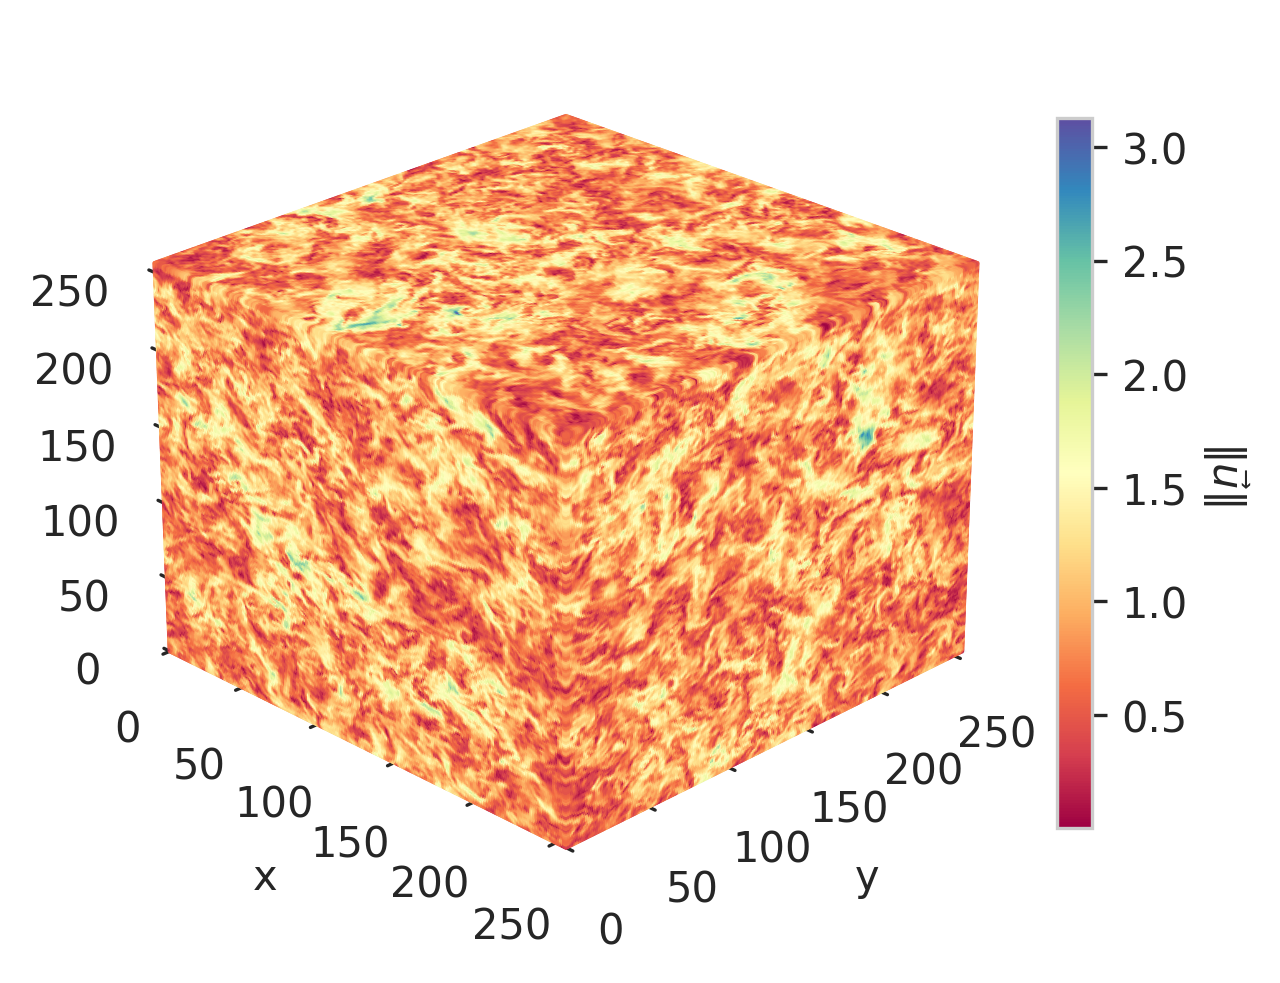

In [5]:
# Plot for velocity surfaces
sns.set_style("whitegrid")
plt.rcParams["image.cmap"] = "Spectral"

# Create a new figure and 3D axis
fig = plt.figure(figsize=(6.4 * 0.8, 4.8 * 0.8), dpi=300)
ax = fig.add_subplot(111, projection="3d")
ax.view_init(azim=-45)

# Trick to put the z-ticks on the left of the 3d plot
tmp_planes = ax.zaxis._PLANES
ax.zaxis._PLANES = (
    tmp_planes[2],
    tmp_planes[3],
    tmp_planes[0],
    tmp_planes[1],
    tmp_planes[4],
    tmp_planes[5],
)
view_1 = (25, -135)
view_2 = (25, -45)
init_view = view_2
ax.view_init(*init_view)

# Choose type of plot and data
plot_imshows(ax, "external_faces_1", Norm_U[:, :, :], boundaries=None)  # , stride=0


# Add the colorbar
vmin = np.min(Norm_U)
vmax = np.max(Norm_U)
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(cmap="Spectral", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8, aspect=20)
cbar.set_label(r"$\|\vec{u}\|$", rotation=270, labelpad=15)

plt.savefig("Spectral.png")
plt.show()

# Power spectra:


In [ ]:
sns.set_theme(style="ticks", context='notebook', palette='colorblind')
    # Plot for TKE spectrum
    sns.set_style('darkgrid')
    ax3 = fig.add_subplot(gs[0, 2])

    N_half = int(len(wave_numbers_tmp) / 2)

    # Plot using semilogx for x-axis base 2 and semilogy for y-axis base 10
    ax3.semilogx(wave_numbers_tmp[2:N_half],
                 tke_spectrum_tmp[2:N_half],
                 base=2, markersize=2.5, marker='o')

    # To plot y-values on base 10, simply use semilogy
    ax3.semilogy(wave_numbers_tmp[2:N_half],
                 (wave_numbers_tmp[2:N_half]**(-5/3)),
                 'r--')

    ax3.set_title('Power Spectrum', fontweight="bold")
    ax3.set_xlabel('k', fontweight="bold")
    ax3.set_ylabel('E(k)', fontweight="bold")
    ax3.legend(['E(k)', r'$\mathrm{k^{-5/3}}$'], loc='lower left')


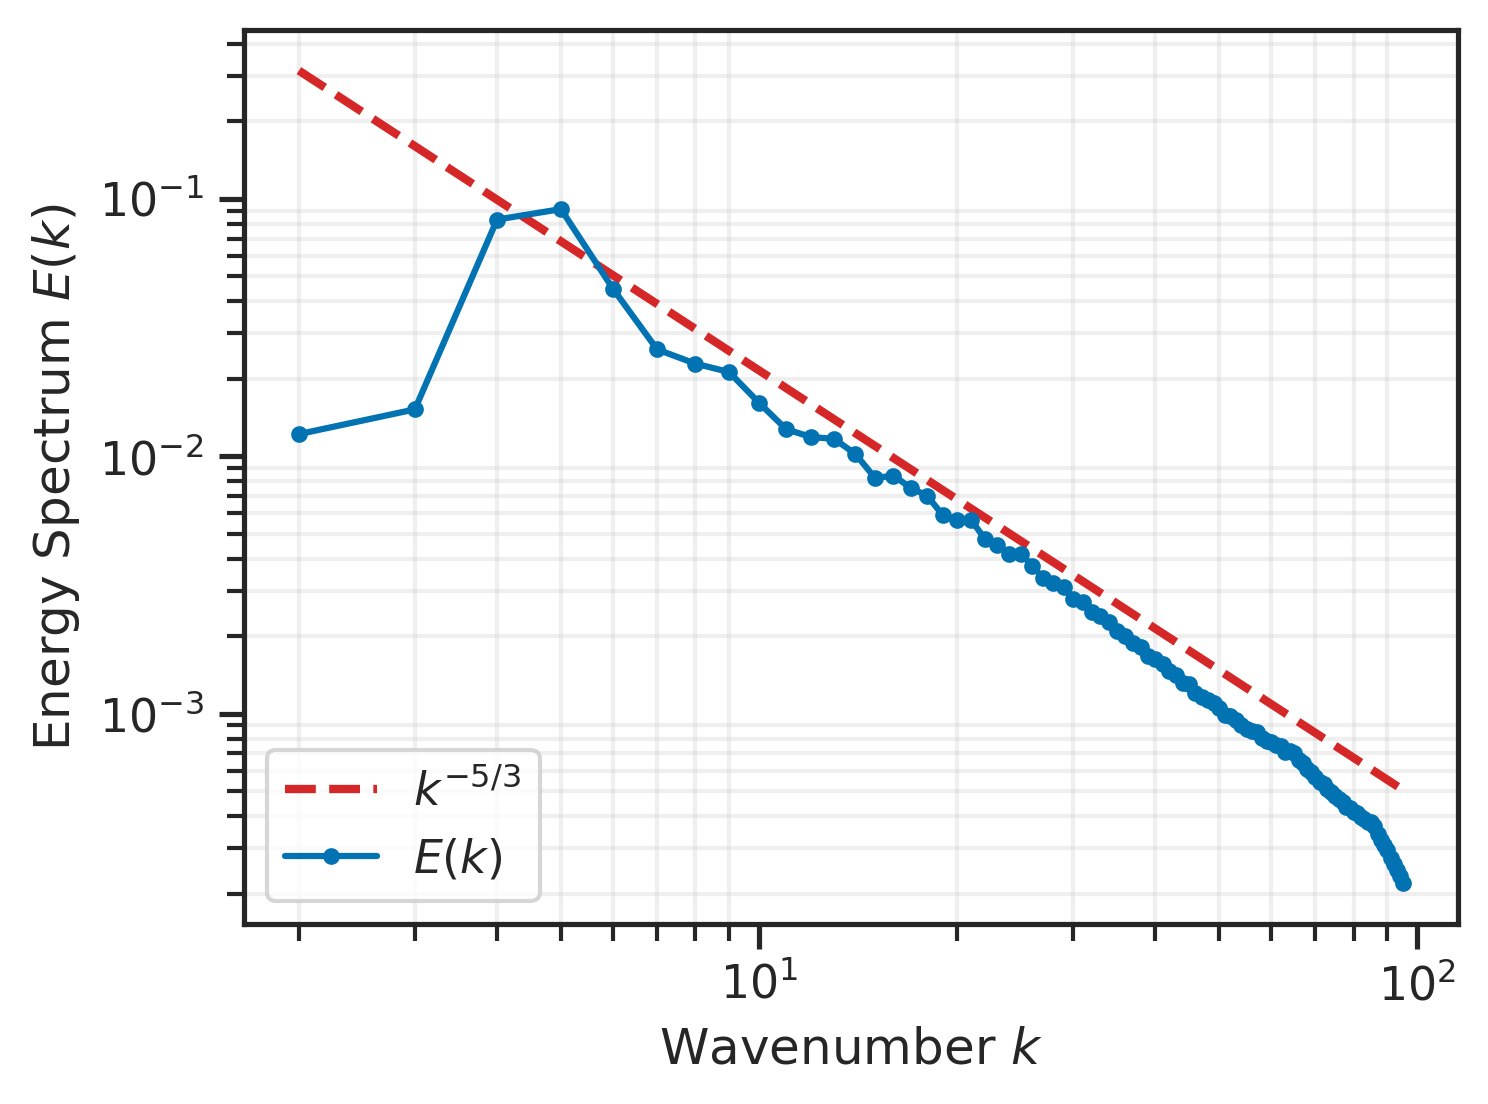

In [45]:
sns.set_theme(style="ticks", context="notebook", palette="colorblind")
fig = plt.figure(figsize=(6.4 * 0.8, 4.8 * 0.8), dpi=300)

# Calculate half-length
N_half = len(wave_numbers) // 2

# Add the -5/3 slope reference line
plt.loglog(
    wave_numbers[2:N_half],
    (wave_numbers[2:N_half] ** (-5 / 3)),
    "tab:red",
    linestyle="--",
    linewidth=2,
    label=r"$k^{-5/3}$",
)

# Create the log-log plot
plt.loglog(
    wave_numbers[2:N_half],
    tke_spectrum[2:N_half],
    "o-",
    markersize=3,
    linewidth=1.5,
    label=r"$E(k)$",
)

# Set labels and title
plt.xlabel(rf"Wavenumber $k$")
plt.ylabel(rf"Energy Spectrum $E(k)$")
# plt.set_title('Turbulent Kinetic Energy Power Spectrum', fontweight="bold", fontsize=14)

# Add legend
plt.legend(loc="lower left")

# Add grid
plt.grid(True, which="both", ls="-", alpha=0.3)

# Adjust layout
plt.tight_layout()

# Save and show
# plt.savefig('power_spectrum.png', dpi=300, bbox_inches='tight')
plt.grid()
plt.show()